In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving customers.csv to customers.csv
Saving order_items.csv to order_items.csv
Saving orders.csv to orders.csv
Saving products.csv to products.csv
Saving sales_cleaned.csv to sales_cleaned.csv


In [ ]:
uploaded.keys()

dict_keys(['customers (3).csv', 'order_items (3).csv', 'orders (2).csv', 'products (2).csv', 'sales_cleaned (1).csv'])

In [12]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales_cleaned.csv")

In [ ]:
print("Customer Shape: ",customers.shape)
print("Order Shape: ",orders.shape)
print("Order_items Shape: ",order_items.shape)
print("Products Shape: ",products.shape)
print("Sales Shape: ",sales.shape)

Customer Shape:  (300, 3)
Order Shape:  (1000, 4)
Order_items Shape:  (2000, 4)
Products Shape:  (50, 3)
Sales Shape:  (1625, 10)


In [ ]:
customers.head()

,customer_id,country,signup_date
0,1,Spain,2023-05-15
1,2,Italy,2023-02-10
2,3,Spain,2023-10-23
3,4,France,2023-01-03
4,5,Italy,2024-02-05


In [ ]:
orders.head()

,order_id,customer_id,order_date,status
0,1,103,2024-10-31,Completed
1,2,271,2024-10-12,Completed
2,3,107,2024-05-23,Completed
3,4,72,2024-01-19,Completed
4,5,189,2024-01-18,Completed


In [ ]:
order_items.head()

,order_id,product_id,quantity,price
0,508,48,3,108
1,290,18,2,93
2,295,16,2,27
3,451,39,2,54
4,904,4,4,117


In [ ]:
products.head()

,product_id,product_name,category
0,1,Product_1,Body
1,2,Product_2,Skin
2,3,Product_3,Hair
3,4,Product_4,Body
4,5,Product_5,Skin


In [ ]:
sales.head()

,order_id,product_id,quantity,price,Revenue,customer_id,order_date,status,year,month
0,290,18,2,93,186,256,2024-08-26,Completed,2024,8
1,290,20,4,102,408,256,2024-08-26,Completed,2024,8
2,290,19,1,25,25,256,2024-08-26,Completed,2024,8
3,295,16,2,27,54,54,2024-06-25,Completed,2024,6
4,295,13,3,48,144,54,2024-06-25,Completed,2024,6


In [ ]:
customers.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
status,0


In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
status,0


In [ ]:
order_items.isnull().sum()

,0
order_id,0
product_id,0
quantity,0
price,0


In [ ]:
products.isnull().sum()

,0
product_id,0
product_name,0
category,0


In [ ]:
sales.isnull().sum()

,0
order_id,0
product_id,0
quantity,0
price,0
Revenue,0
customer_id,0
order_date,0
status,0
year,0
month,0


In [ ]:
customers.duplicated().sum()

np.int64(0)

In [ ]:
orders.duplicated().sum()

np.int64(0)

In [ ]:
order_items.duplicated().sum()

np.int64(0)

In [ ]:
products.duplicated().sum()

np.int64(0)

In [ ]:
sales.duplicated().sum()

np.int64(0)

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     1000 non-null   int64 
 1   customer_id  1000 non-null   int64 
 2   order_date   1000 non-null   object
 3   status       1000 non-null   object
dtypes: int64(2), object(2)
memory usage: 31.4+ KB


In [ ]:
#Convert dates
orders['order_date'] = pd.to_datetime(orders['order_date'])
#Drop duplicate items
orders = orders.drop_duplicates()

In [ ]:
total_revenue = sales['Revenue'].sum()
print("Total Revenue: ",total_revenue)

total_orders = orders['order_id'].nunique()
print("Total Orders: ",total_orders)

total_customers = customers['customer_id'].nunique()
print("Total Customers: ",total_customers)

avg_order = total_revenue / total_orders
print("Average Order Value: ",avg_order)

Total Revenue:  311111
Total Orders:  1000
Total Customers:  300
Average Order Value:  311.111


In [ ]:
#Customer Analysis

#Calculate revenue per customer:
customer_revenue = sales.groupby(
    'customer_id'
)['Revenue'].sum().sort_values(
    ascending=False
)

customer_revenue.head(10)

,Revenue
customer_id,
13,5048
39,4564
152,4309
144,3420
76,3330
113,2960
126,2960
130,2949
277,2939


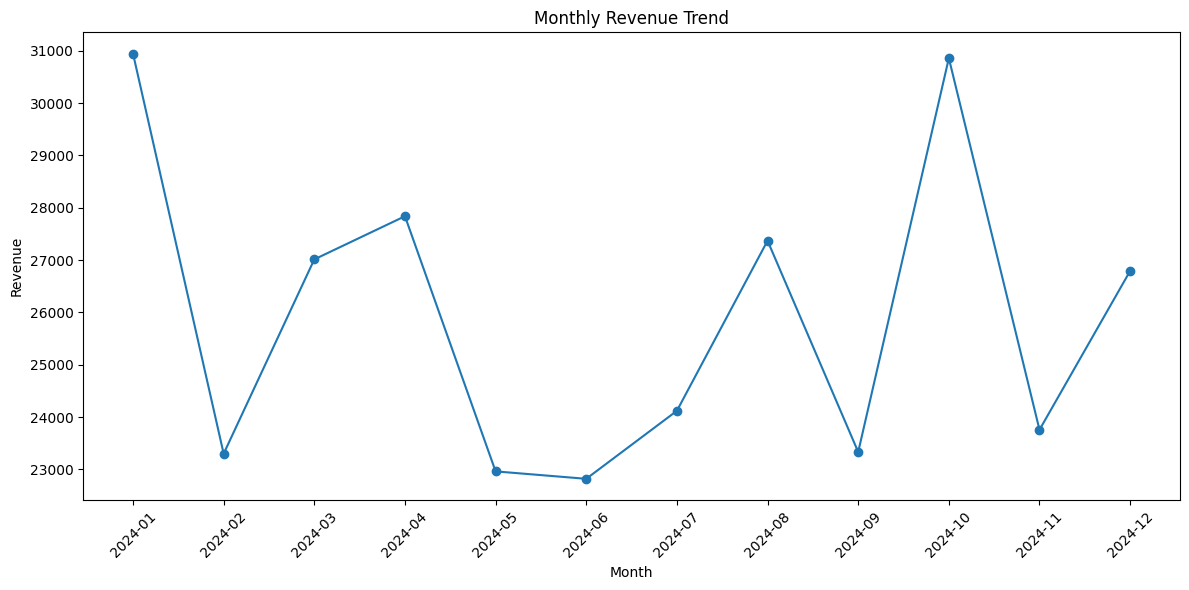

In [19]:
# Monthly Revenue:

sales['order_date'] = pd.to_datetime(sales['order_date'])

monthly_sales = sales.groupby(
    sales['order_date'].dt.to_period('M')
)['Revenue'].sum()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

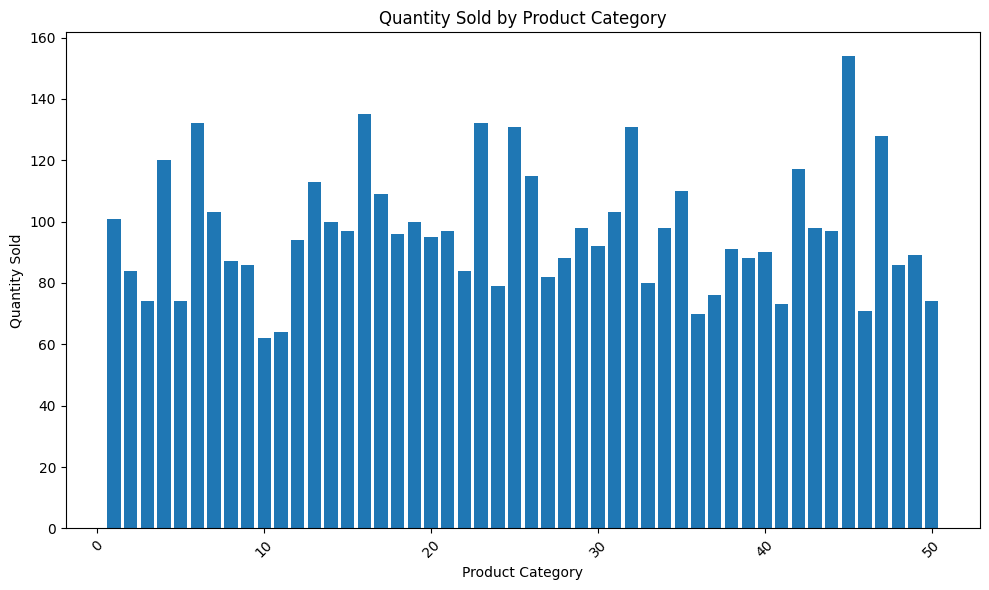

In [18]:
# Quantity Sold by Product Category:

quantity_category = sales.groupby(
    'product_id'
)['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    quantity_category.index,
    quantity_category.values
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

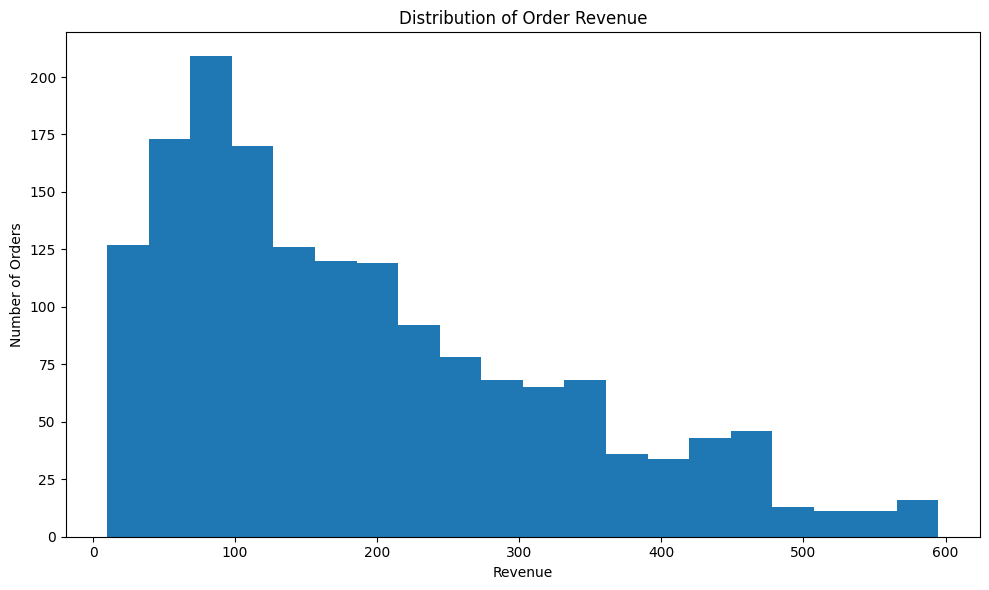

In [20]:
# Order Value Distribution:

plt.figure(figsize=(10, 6))

plt.hist(
    sales['Revenue'],
    bins=20
)

plt.title("Distribution of Order Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()